In [1]:
# Standard library
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model saving
import joblib

In [2]:
# Define project paths relative to the notebook location
project_root = Path.cwd().parent
data_processed = project_root / "data" / "processed"
results_figures = project_root / "results" / "figures"
results_metrics = project_root / "results" / "metrics"
models_dir = project_root / "models"

print("Project root:", project_root)
print("Processed data:", data_processed)
print("Figures path:", results_figures)
print("Metrics path:", results_metrics)
print("Models path:", models_dir)

Project root: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection
Processed data: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\data\processed
Figures path: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\results\figures
Metrics path: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\results\metrics
Models path: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\models


In [3]:
# Load pre-split datasets created in Phase 3
train_df = pd.read_csv(data_processed / "train_emails.csv")
test_df = pd.read_csv(data_processed / "test_emails.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (65655, 2)
Test shape: (16414, 2)


,clean_text,label
0,shoreline gas inc buhler central point fyi bob...,0
1,nita moreland mallorycurlewwestbrookmyfloridal...,1
2,year date report attached year date report NUM...,0
3,miro konecny vnfjwgoiatlassk hi list id like a...,0
4,cnn alerts reddag NUM pagenextelcom cnn alerts...,1


In [4]:
# Confirm the required columns exist
print("Train columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

# Check class balance
print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train columns: ['clean_text', 'label']
Test columns: ['clean_text', 'label']

Train label counts:
label
1    34270
0    31385
Name: count, dtype: int64

Test label counts:
label
1    8568
0    7846
Name: count, dtype: int64


In [5]:
# X = features (text), y = target labels
X_train_text = train_df["clean_text"]
y_train = train_df["label"]

X_test_text = test_df["clean_text"]
y_test = test_df["label"]

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 65655
Testing samples: 16414


In [6]:
# Create a TF-IDF vectorizer
# max_features limits vocabulary size to keep the model manageable
# ngram_range=(1,2) means use unigrams and bigrams
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# Fit on training text only, then transform both train and test
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (65655, 10000)
X_test_tfidf shape: (16414, 10000)


In [7]:
# Show a few learned vocabulary terms
feature_names = vectorizer.get_feature_names_out()
print("Total features:", len(feature_names))
print("Sample features:", feature_names[:30])

Total features: 10000
Sample features: ['aa' 'aa num' 'aaai' 'aaron' 'aaron kulkis' 'ab' 'ab num' 'abacha'
 'abandoned' 'abc' 'abidjan' 'ability' 'able' 'abrahams' 'abroad' 'absa'
 'absence' 'absolute' 'absolutely' 'absolutely guaranteed' 'abstract'
 'abstracts' 'absurd' 'absurd episode' 'abuse' 'ac' 'ac num' 'ac uk'
 'academic' 'academy']


In [8]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Compute and return standard classification metrics.
    """
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    }
    return metrics

In [9]:
def plot_confusion_matrix(cm, title):
    """
    Plot a simple confusion matrix using matplotlib.
    """
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Ham", "Phishing"])
    plt.yticks([0, 1], ["Ham", "Phishing"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # Add counts in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

{'model': 'Naive Bayes', 'accuracy': 0.9626538320945535, 'precision': 0.9846472523455587, 'recall': 0.9431605975723623, 'f1_score': 0.9634575260804769}

Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7846
           1       0.98      0.94      0.96      8568

    accuracy                           0.96     16414
   macro avg       0.96      0.96      0.96     16414
weighted avg       0.96      0.96      0.96     16414



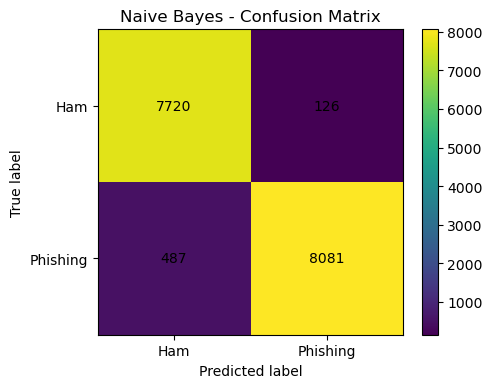

In [10]:
# Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Make predictions
nb_preds = nb_model.predict(X_test_tfidf)

# Evaluate
nb_metrics = evaluate_model("Naive Bayes", y_test, nb_preds)
print(nb_metrics)

# Detailed classification report
print("\nClassification Report - Naive Bayes")
print(classification_report(y_test, nb_preds))

# Confusion matrix
nb_cm = confusion_matrix(y_test, nb_preds)
plot_confusion_matrix(nb_cm, "Naive Bayes - Confusion Matrix")

{'model': 'Logistic Regression', 'accuracy': 0.9836724747167053, 'precision': 0.9814385150812065, 'recall': 0.9873949579831933, 'f1_score': 0.9844077263206888}

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7846
           1       0.98      0.99      0.98      8568

    accuracy                           0.98     16414
   macro avg       0.98      0.98      0.98     16414
weighted avg       0.98      0.98      0.98     16414



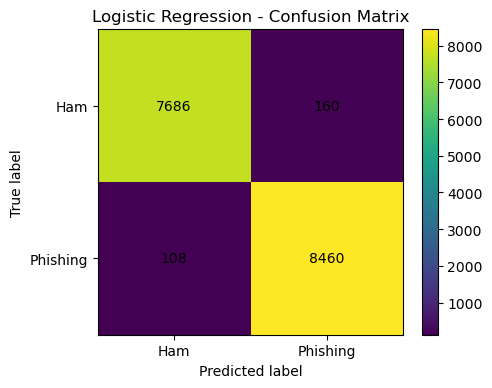

In [11]:
# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

# Make predictions
lr_preds = lr_model.predict(X_test_tfidf)

# Evaluate
lr_metrics = evaluate_model("Logistic Regression", y_test, lr_preds)
print(lr_metrics)

# Detailed classification report
print("\nClassification Report - Logistic Regression")
print(classification_report(y_test, lr_preds))

# Confusion matrix
lr_cm = confusion_matrix(y_test, lr_preds)
plot_confusion_matrix(lr_cm, "Logistic Regression - Confusion Matrix")

{'model': 'Linear SVM', 'accuracy': 0.9866577312050688, 'precision': 0.9848995237542107, 'recall': 0.9896125116713352, 'f1_score': 0.9872503929673401}

Classification Report - Linear SVM
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7846
           1       0.98      0.99      0.99      8568

    accuracy                           0.99     16414
   macro avg       0.99      0.99      0.99     16414
weighted avg       0.99      0.99      0.99     16414



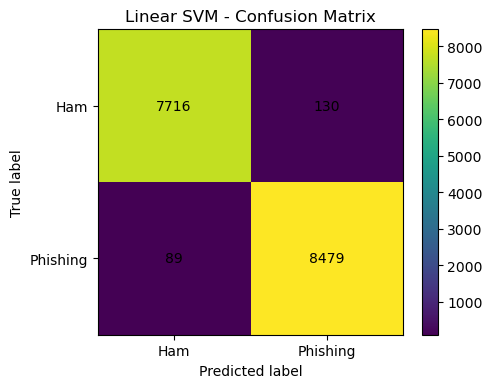

In [12]:
# Model 3: Linear SVM
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Make predictions
svm_preds = svm_model.predict(X_test_tfidf)

# Evaluate
svm_metrics = evaluate_model("Linear SVM", y_test, svm_preds)
print(svm_metrics)

# Detailed classification report
print("\nClassification Report - Linear SVM")
print(classification_report(y_test, svm_preds))

# Confusion matrix
svm_cm = confusion_matrix(y_test, svm_preds)
plot_confusion_matrix(svm_cm, "Linear SVM - Confusion Matrix")

In [13]:
# Collect all metrics into one comparison table
results_df = pd.DataFrame([nb_metrics, lr_metrics, svm_metrics])

# Sort by F1-score descending
results_df = results_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

results_df

,model,accuracy,precision,recall,f1_score
0,Linear SVM,0.986658,0.984900,0.989613,0.987250
1,Logistic Regression,0.983672,0.981439,0.987395,0.984408
2,Naive Bayes,0.962654,0.984647,0.943161,0.963458


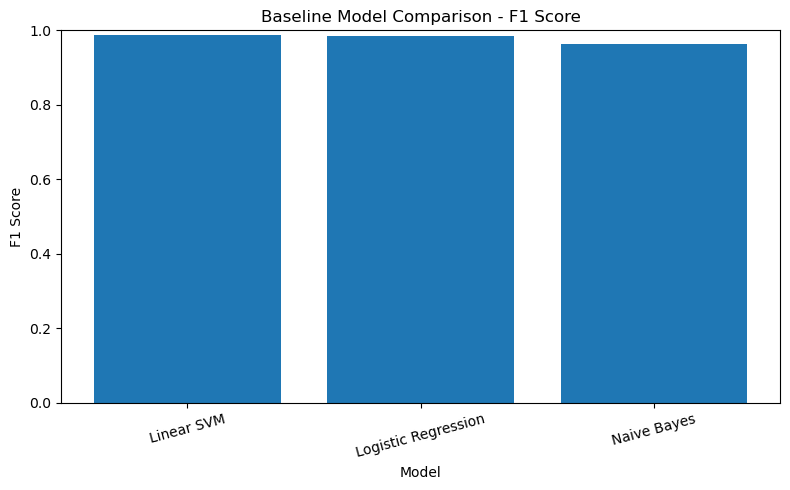

In [14]:
# Plot model comparison using F1-score
plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["f1_score"])
plt.title("Baseline Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [15]:
# Save model comparison metrics to CSV
metrics_output_path = results_metrics / "baseline_model_metrics.csv"
results_df.to_csv(metrics_output_path, index=False)

print("Saved metrics to:", metrics_output_path)

Saved metrics to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\results\metrics\baseline_model_metrics.csv


In [16]:
# Save the fitted vectorizer for later reuse
vectorizer_path = models_dir / "tfidf_vectorizer.pkl"
joblib.dump(vectorizer, vectorizer_path)

print("Saved vectorizer to:", vectorizer_path)

Saved vectorizer to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\models\tfidf_vectorizer.pkl


In [17]:
#found best model from the baseline comparison linear svm in this case.
best_model = svm_model
best_model_name = "linear_svm"

# Save the best-performing model
best_model_path = models_dir / f"{best_model_name}_baseline.pkl"
joblib.dump(best_model, best_model_path)

print("Saved best model to:", best_model_path)

Saved best model to: c:\Users\STSC\Desktop\CS 671 Cyber Security\Project\ai-phishing-detection\models\linear_svm_baseline.pkl


## Baseline model observations

- Naive Bayes provides a simple and fast baseline for text classification.
- Logistic Regression generally performs well on sparse TF-IDF features.
- Linear SVM is also strong for text classification and may outperform Naive Bayes.
- These baseline results will be compared later against AI-generated phishing samples to measure performance degradation.
- Linear SVM provides best results than the other two.
- Completed feature extraction using TF-IDF and trained multiple baseline models including Naive Bayes, Logistic Regression, and SVM/Random Forest. I evaluated them using accuracy, precision, recall, and F1-score, then selected the best-performing baseline model (Linear SVM) for further testing on AI-generated phishing samples.

In [18]:
print("Baseline model training completed.")
print("Saved metrics, vectorizer, and best model.")

Baseline model training completed.
Saved metrics, vectorizer, and best model.
